# DATA PROCESSING

In [1]:
# importy knizni
import warnings
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import kpss
import functions
import importlib
from pathlib import Path
importlib.reload(functions)
from functions import forward_selection

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")

Importy uspesne.


In [2]:
# konfiguracia a stiahnutie dat
# vypisanie info o datach a kontrola chybajucich hodnot

DATA_PATH  = r"C:\Users\adamv\Desktop\ADAM\VS\Diplomovka\excel\data.xlsx" 
SHEET_NAME = "all"

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, engine="openpyxl")

df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")

print(f"Nacitane: {df_raw.shape[0]} riadkov, {df_raw.shape[1]} stlpcov")
print(f"Obdobie : {df_raw.index.min().date()} az {df_raw.index.max().date()}")
print("Stlpce  :", list(df_raw.columns))

missing = df_raw.isnull().sum()
if missing.any():
    print("\nChybajuce hodnoty:")
    print(missing[missing > 0])
else:
    print("\nZiadne chybajuce hodnoty.")


Nacitane: 312 riadkov, 16 stlpcov
Obdobie : 2000-01-01 az 2025-12-01
Stlpce  : ['pp', 'cpi', 'ipcv_priemysel', 'export_celkovy_sa', 'trzby_priemysel_sa', 'kurz_usd_eur', 'sadzba_3m_euribor', 'uvery_celkom', 'vklady_nefinancne_podniky', 'prod_dev', 'prod_exp', 'ind_conf', 'fin_stock', 'pp_sa', 'unem_prod', 'inflation']

Ziadne chybajuce hodnoty.


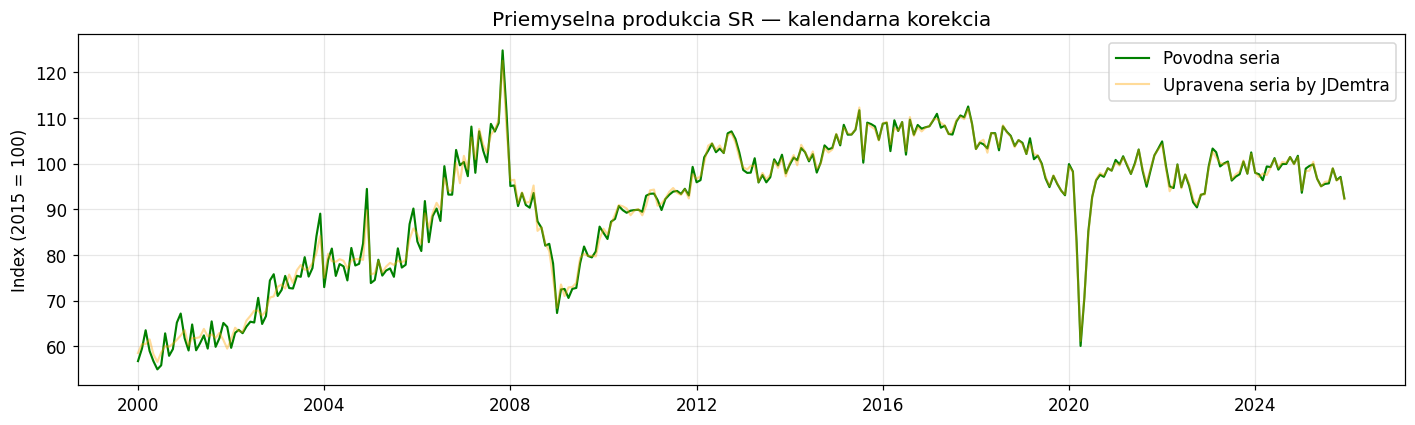

In [3]:
# graficke porovnanie casovych radov: povodne data vs. SA upravene cez SW JDemtra

df = df_raw.copy()
fig, ax = plt.subplots()
ax.plot(df.index, df["pp"],    color="green",  linewidth=1.4, label="Povodna seria")
ax.plot(df.index, df["pp_sa"], color = "orange", linewidth = 1.4, label = "Upravena seria by JDemtra", alpha = 0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Priemyselna produkcia SR — kalendarna korekcia")
ax.set_ylabel("Index (2015 = 100)")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/01_cielova_premenna.png", dpi=150)
plt.show()


In [4]:
# kontrola stacionarity premennych
# premenna je stacionarna len ak ADF zamieta H0 A KPSS nezamieta H0.

EXOG_CANDIDATES = df.columns.tolist()

df_to_test = df[EXOG_CANDIDATES].copy()

print("=== ADF test — urovne ===")
non_stationary = functions.adf_test(df)

print("\n=== KPSS test — urovne ===")
for col in EXOG_CANDIDATES:
    stat, pval, _, _ = kpss(df[col].dropna(), regression="c", nlags="auto")
    verdict = "nestacionarna" if pval < 0.05 else "stacionarna"
    print(f"  {col}: stat={stat:.4f}, p={pval:.4f}  [{verdict}]")

print("\nNestacionarne (podla ADF):", non_stationary)


=== ADF test — urovne ===

--- pp ---
ADF stat: -2.4769
p-val: 0.1212
Nezam. H0: nestacionarny

--- cpi ---
ADF stat: 0.8354
p-val: 0.9922
Nezam. H0: nestacionarny

--- ipcv_priemysel ---
ADF stat: -1.0786
p-val: 0.7235
Nezam. H0: nestacionarny

--- export_celkovy_sa ---
ADF stat: -0.3847
p-val: 0.9126
Nezam. H0: nestacionarny

--- trzby_priemysel_sa ---
ADF stat: -0.7802
p-val: 0.8249
Nezam. H0: nestacionarny

--- kurz_usd_eur ---
ADF stat: -2.3097
p-val: 0.1688
Nezam. H0: nestacionarny

--- sadzba_3m_euribor ---
ADF stat: -2.3198
p-val: 0.1657
Nezam. H0: nestacionarny

--- uvery_celkom ---
ADF stat: 1.8306
p-val: 0.9984
Nezam. H0: nestacionarny

--- vklady_nefinancne_podniky ---
ADF stat: 1.3944
p-val: 0.9971
Nezam. H0: nestacionarny

--- prod_dev ---
ADF stat: -5.7978
p-val: 0.0000
Zam. H0: stacionarny

--- prod_exp ---
ADF stat: -3.5767
p-val: 0.0062
Zam. H0: stacionarny

--- ind_conf ---
ADF stat: -4.0928
p-val: 0.0010
Zam. H0: stacionarny

--- fin_stock ---
ADF stat: -2.8459
p-va

In [5]:
# diferencovanie nestacionarnych premennych

df_diff = df[non_stationary].diff(1).dropna()
print("=== ADF test — prve diferencie ===")
non_stationary_diff = functions.adf_test(df_diff)

if non_stationary_diff:
    print("\nPremenné stale nestacionarne po 1. diferencii (zvazit I(2)):")
    print(non_stationary_diff)
else:
    print("\nVsetky premenne su stacionarne po 1. diferencii.")


=== ADF test — prve diferencie ===

--- pp ---
ADF stat: -4.8234
p-val: 0.0000
Zam. H0: stacionarny

--- cpi ---
ADF stat: -3.5451
p-val: 0.0069
Zam. H0: stacionarny

--- ipcv_priemysel ---
ADF stat: -3.8703
p-val: 0.0023
Zam. H0: stacionarny

--- export_celkovy_sa ---
ADF stat: -13.8271
p-val: 0.0000
Zam. H0: stacionarny

--- trzby_priemysel_sa ---
ADF stat: -3.9703
p-val: 0.0016
Zam. H0: stacionarny

--- kurz_usd_eur ---
ADF stat: -12.8393
p-val: 0.0000
Zam. H0: stacionarny

--- sadzba_3m_euribor ---
ADF stat: -4.4214
p-val: 0.0003
Zam. H0: stacionarny

--- uvery_celkom ---
ADF stat: -3.9095
p-val: 0.0020
Zam. H0: stacionarny

--- vklady_nefinancne_podniky ---
ADF stat: -4.0775
p-val: 0.0011
Zam. H0: stacionarny

--- fin_stock ---
ADF stat: -11.6169
p-val: 0.0000
Zam. H0: stacionarny

--- pp_sa ---
ADF stat: -10.9810
p-val: 0.0000
Zam. H0: stacionarny

--- unem_prod ---
ADF stat: -6.7555
p-val: 0.0000
Zam. H0: stacionarny

Vsetky premenne su stacionarne po 1. diferencii.


In [6]:
df_diff["crisis_dummy"] = 0
df_diff.loc["2008-01-01", "crisis_dummy"] = 1

In [8]:
# vyber premennych do modelu na zaklade znizovania BIC
df.drop(columns=["pp"], inplace = True)
selected_cols = forward_selection(df,"pp_sa")

BIC forward selection:
--------------------------------------------------
  + 'export_celkovy_sa'  BIC = 1550.87
  + 'trzby_priemysel_sa'  BIC = 1539.07
  + 'cpi'  BIC = 1534.27
  Zastavenie — pridanie ziadnej premennej nezlepsuje BIC.
--------------------------------------------------
Vybrane premenne: ['export_celkovy_sa', 'trzby_priemysel_sa', 'cpi']
Finalny BIC    : 1534.27


In [24]:
df_diff = df_diff.reset_index()
df_diff.to_csv('../../excel/data_mod.csv', index=False)